# Train, Validate, and Reward-Shape with the Time2Success Model

Three stages in one notebook:
1. Train the MLP regressor on `state_space_time2success_dataset/dataset.npz`
2. Validate qualitatively with a successful-episode video and a failed-episode video
3. Use the trained model as a shaped reward to train a new policy, compare against stage 1

Run and check each stage before moving to the next — don't run the whole
notebook top-to-bottom blindly, since stage 3 is a multi-hour commitment.

## Stage 1: Train the MLP time2success regressor

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import json, os

DATASET_PATH = "./data/state_space_dataset/dataset.npz"
data = np.load(DATASET_PATH)
X, y_steps, y_seconds, episode_ids = data["X"], data["y_steps"], data["y_seconds"], data["episode_ids"]

with open("./data/state_space_dataset/dataset_summary.json") as f:
    summary = json.load(f)
print(summary)

OBS_DIM = X.shape[1]
print(f"Rows: {X.shape[0]}, obs dim: {OBS_DIM}, episodes: {len(set(episode_ids))}")

{'total_rows': 5771, 'total_episodes': 100, 'obs_dim': 39, 'dt_sec': 0.0125, 'source_policy': './checkpoints/peg_insert_side/sac_peg_insert_final', 'successful_only': True, 'checkpoint_diversity': False}
Rows: 5771, obs dim: 39, episodes: 100


In [2]:
# Group-aware split — by episode, not by row (avoids leakage, per earlier discussion)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
train_idx, val_idx = next(gss.split(X, y_steps, groups=episode_ids))

X_train, y_train = X[train_idx], y_steps[train_idx]  # training on STEPS, not seconds — more stable target
X_val, y_val = X[val_idx], y_steps[val_idx]
print(f"Train rows: {len(X_train)}, Val rows: {len(X_val)}")

Train rows: 4981, Val rows: 790


In [3]:
# Group-aware split (already have this)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
train_idx, val_idx = next(gss.split(X, y_steps, groups=episode_ids))
X_train, y_train = X[train_idx], y_steps[train_idx]
X_val, y_val = X[val_idx], y_steps[val_idx]

# --- NEW: normalization goes here, computed from TRAIN only ---
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
y_mean, y_std = y_train.mean(), y_train.std()

X_train_n = (X_train - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
X_val_n = (X_val - X_mean) / X_std
y_val_n = (y_val - y_mean) / y_std

# Then build DataLoaders from the NORMALIZED arrays, not the raw ones
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_n), torch.tensor(y_train_n)),
                           batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_n), torch.tensor(y_val_n)), batch_size=256)

In [6]:
# Model definition. NOTE: train_loader/val_loader come from the
# NORMALIZATION cell above (X_train_n/y_train_n) — this cell does NOT
# rebuild them from raw data, unlike the earlier version of this notebook
# which silently overwrote the normalized loaders here (that was Bug 1).

class Time2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = "cuda" if torch.cuda.is_available() else "cpu"
t2s_model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
optimizer = torch.optim.Adam(t2s_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# train_loader / val_loader intentionally NOT rebuilt here —
# they already exist from the normalization cell above, and are the
# NORMALIZED versions. If you re-run cells out of order and this errors
# with NameError, re-run the normalization cell first.
# print("Using existing train_loader/val_loader (should be the NORMALIZED ones)")
# print(f"Confirm: y_train_n mean~{y_train_n.mean():.3f}, std~{y_train_n.std():.3f} "
#       f"(should be ~0 and ~1 if normalization is actually in effect)")

In [6]:
EPOCHS = 100 # Number of training epochs
best_val_loss = float("inf")
os.makedirs("./checkpoints/time2success", exist_ok=True)

for epoch in range(EPOCHS):
    t2s_model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = t2s_model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(X_train)

    t2s_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += loss_fn(t2s_model(xb), yb).item() * xb.size(0)
    val_loss /= len(X_val)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(t2s_model.state_dict(), "./checkpoints/time2success/time2success_state_model_best.pt")

    if epoch % 5 == 0:
        # Loss is now on NORMALIZED scale (unitless, roughly 0-1 range for a
        # reasonably fit model) — NOT steps^2 anymore. If these numbers still
        # look like hundreds, normalization still isn\'t actually being used.
        print(f"epoch {epoch}: train MSE(norm)={train_loss:.4f}, val MSE(norm)={val_loss:.4f}")

torch.save(t2s_model.state_dict(), "./checkpoints/time2success/time2success_state_model_final.pt")

# Save normalization stats ALONGSIDE the model — required to use the model
# correctly later (Stage 2 validation, Stage 3 reward shaping), and survives
# kernel restarts (unlike keeping X_mean/X_std only as notebook variables).
np.savez("./checkpoints/time2success/normalization.npz",
         X_mean=X_mean, X_std=X_std, y_mean=y_mean, y_std=y_std)

print(f"\nBest val MSE (normalized): {best_val_loss:.4f}")
print("Saved model + normalization.npz to ./checkpoints/time2success/")

epoch 0: train MSE(norm)=0.0016, val MSE(norm)=0.6818
epoch 5: train MSE(norm)=0.0016, val MSE(norm)=0.6872
epoch 10: train MSE(norm)=0.0023, val MSE(norm)=0.6983
epoch 15: train MSE(norm)=0.0013, val MSE(norm)=0.6410
epoch 20: train MSE(norm)=0.0015, val MSE(norm)=0.6533
epoch 25: train MSE(norm)=0.0009, val MSE(norm)=0.6309
epoch 30: train MSE(norm)=0.0010, val MSE(norm)=0.6643
epoch 35: train MSE(norm)=0.0008, val MSE(norm)=0.6649
epoch 40: train MSE(norm)=0.0008, val MSE(norm)=0.6472
epoch 45: train MSE(norm)=0.0009, val MSE(norm)=0.7220
epoch 50: train MSE(norm)=0.0007, val MSE(norm)=0.6609
epoch 55: train MSE(norm)=0.0005, val MSE(norm)=0.6650
epoch 60: train MSE(norm)=0.0045, val MSE(norm)=0.7177
epoch 65: train MSE(norm)=0.0028, val MSE(norm)=0.6134
epoch 70: train MSE(norm)=0.0011, val MSE(norm)=0.5945
epoch 75: train MSE(norm)=0.0004, val MSE(norm)=0.6399
epoch 80: train MSE(norm)=0.0003, val MSE(norm)=0.6500
epoch 85: train MSE(norm)=0.0017, val MSE(norm)=0.6508
epoch 90: tr

**Check before moving on:** is val RMSE reasonably small relative to typical
episode length (~100-500 steps)? A val RMSE of, say, 20-40 steps is usable;
one close to the label's own standard deviation means the model hasn't
learned much beyond predicting the mean — worth checking
`y_train.std()` for comparison.

## Stage 2: Validate with a successful video and a failed video

Records two full rollouts — one that succeeds, one that fails — with
video, and overlays the model's per-frame prediction against ground truth
(where ground truth is well-defined) or against expected qualitative shape
(where it isn't, for the failure case).

In [7]:
import gymnasium as gym
import metaworld
import imageio
from stable_baselines3 import SAC

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
OBS_DIM = _probe.observation_space.shape[0]
_probe.close()

# Policies: final (competent) for the success rollout, an EARLY checkpoint
# for the failure rollout (more reliable than noise-injecting the final
# policy, and matches the "genuine incompetence vs near-miss" distinction
# discussed earlier).
final_model = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_final")
failure_model = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_500000")

# --- Load the time2success model + its normalization stats FROM DISK ---
# explicitly, rather than trusting whatever `t2s_model` currently is in
# memory (which may be stale if cells were re-run out of order, or absent
# entirely in a fresh kernel session).
norm = np.load("./checkpoints/time2success/normalization.npz")
X_mean, X_std = norm["X_mean"], norm["X_std"]
y_mean, y_std = norm["y_mean"].item(), norm["y_std"].item()

eval_model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
eval_model.load_state_dict(torch.load("./checkpoints/time2success/time2success_state_model_best.pt"))
eval_model.eval()

@torch.no_grad()
def predict_t2s(obs):
    # normalize input, run model, DE-normalize output back to real steps.
    # This is the ONE prediction function used everywhere below —
    # earlier version of this notebook had a second, unused
    # `predict_t2s_normalized` and called the raw (buggy) one instead.
    x = torch.tensor((obs - X_mean) / X_std, dtype=torch.float32).unsqueeze(0).to(device)
    pred_norm = eval_model(x).item()
    return pred_norm * y_std + y_mean

In [8]:
def record_and_predict(model, env, out_path, max_steps=500,
                        extra_frames_after_success=30, deterministic=True,
                        action_noise_std=0.0):
    obs, _ = env.reset()
    frames, predictions, actual_labels = [], [], []
    success_step = None
    frames_since_success = 0

    for t in range(max_steps):
        frames.append(env.render())
        pred_steps = predict_t2s(obs)
        # pred_steps = predict_t2s_normalized(obs)
        
        predictions.append(pred_steps)

        action, _ = model.predict(obs, deterministic=deterministic)
        if action_noise_std > 0:
            action = np.clip(action + np.random.normal(0, action_noise_std, size=action.shape),
                              env.action_space.low, env.action_space.high)
        obs, reward, terminated, truncated, info = env.step(action)

        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t

        if success_step is not None:
            frames_since_success += 1
            if frames_since_success >= extra_frames_after_success:
                break
        if terminated or truncated:
            break

    # Ground-truth label only well-defined up to success_step
    for t in range(len(predictions)):
        if success_step is not None and t <= success_step:
            actual_labels.append(success_step - t)
        else:
            actual_labels.append(None)  # undefined post-success or for failures

    imageio.mimsave(out_path, [np.flipud(f) if False else f for f in frames], fps=20)
    return dict(predictions=predictions, actual=actual_labels,
                success_step=success_step, num_frames=len(frames))

**Successful rollout** — use a seed already known to succeed from earlier collection, or retry a few seeds.

In [13]:
succ_result = None
for seed in range(2, 50):
    env = make_env(seed=seed, render_mode="rgb_array")
    result = record_and_predict(final_model, env, "validation_success.mp4", deterministic=True)
    env.close()
    if result["success_step"] is not None:
        succ_result = result
        print(f"Successful rollout recorded: seed={seed}, success_step={result['success_step']}")
        break
if succ_result is None:
    print("No success found in 50 seeds — check final policy is loading correctly")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Successful rollout recorded: seed=2, success_step=52


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


seed 0: success at step 49, pred at t=0: 47.9, pred at success: 0.5
seed 1: success at step 48, pred at t=0: 47.4, pred at success: 0.6
seed 2: success at step 52, pred at t=0: 49.8, pred at success: 4.1
seed 3: success at step 44, pred at t=0: 43.2, pred at success: 0.2
seed 4: success at step 45, pred at t=0: 45.2, pred at success: 2.1
seed 5: success at step 54, pred at t=0: 54.2, pred at success: 1.3
seed 6: success at step 49, pred at t=0: 47.8, pred at success: -1.1
seed 7: success at step 42, pred at t=0: 44.7, pred at success: -1.9
seed 8: success at step 49, pred at t=0: 49.7, pred at success: 1.0
seed 9: success at step 53, pred at t=0: 52.8, pred at success: 2.0


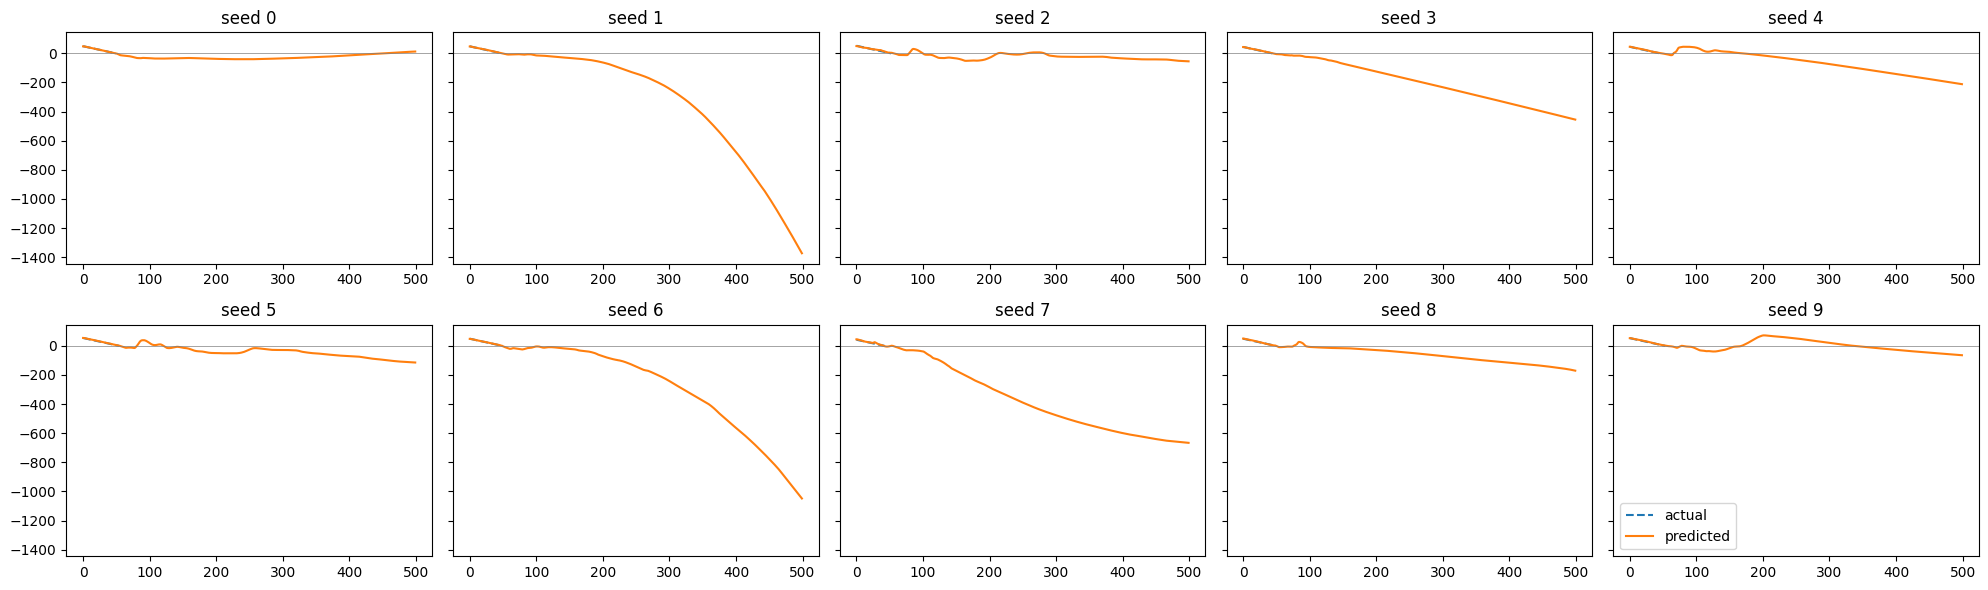

In [9]:
import matplotlib.pyplot as plt

N_SEEDS = 10
seed_results = []
seed = 0
while len(seed_results) < N_SEEDS and seed < 200:
    env = make_env(seed=seed)
    obs, _ = env.reset()
    success_step = None
    predictions, actuals = [], []
    for t in range(500):
        pred_steps = predict_t2s(obs)
        predictions.append(pred_steps)
        action, _ = final_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
        if terminated or truncated:
            break
    env.close()

    if success_step is not None:
        actuals = [success_step - t if t <= success_step else None for t in range(len(predictions))]
        seed_results.append(dict(seed=seed, predictions=predictions, actuals=actuals, success_step=success_step))
        print(f"seed {seed}: success at step {success_step}, "
              f"pred at t=0: {predictions[0]:.1f}, pred at success: {predictions[success_step]:.1f}")
    seed += 1

fig, axes = plt.subplots(2, 5, figsize=(20, 6), sharey=True)
for ax, r in zip(axes.flat, seed_results):
    ax.plot(r["actuals"], "--", label="actual")
    ax.plot(r["predictions"][:len(r["actuals"])], label="predicted")
    ax.set_title(f"seed {r['seed']}")
    ax.axhline(0, color="gray", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Failed rollout** — the final policy may rarely fail deterministically.
Inject action noise to reliably force a failure for this comparison.

In [14]:
fail_result = None
for seed in range(2,50):
    env = make_env(seed=1000 + seed, render_mode="rgb_array")
    # Using the early (undertrained) checkpoint, no noise needed on top —
    # it fails often enough on its own.
    result = record_and_predict(failure_model, env, "validation_failure.mp4",
                                 deterministic=True, action_noise_std=0.0)
    env.close()
    if result["success_step"] is None:
        fail_result = result
        print(f"Failed rollout recorded: seed={1000+seed}")
        break
    # early stop
    if seed > 10:
        print("Early stop reached without finding a failure rollout")
        break
if fail_result is None:
    print("Even the early checkpoint kept succeeding — try a smaller-numbered checkpoint")

Failed rollout recorded: seed=1008


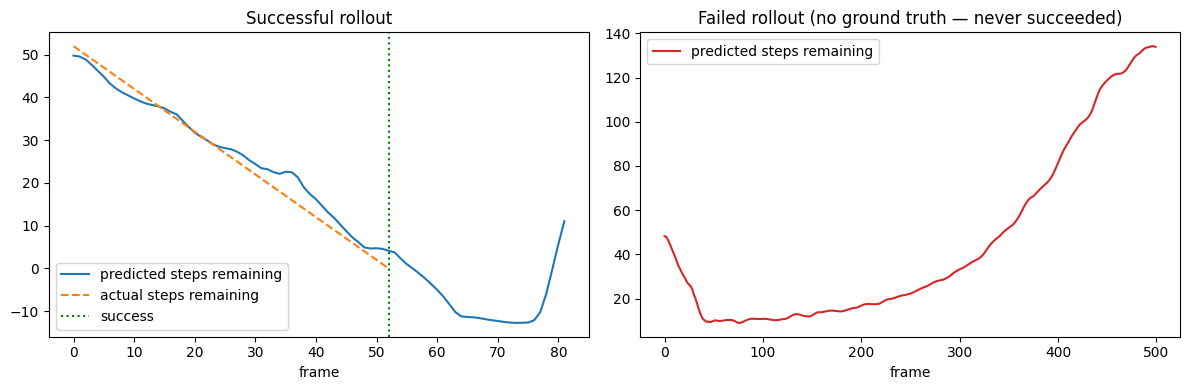

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(succ_result["predictions"], label="predicted steps remaining")
actual_plot = [a if a is not None else np.nan for a in succ_result["actual"]]
axes[0].plot(actual_plot, label="actual steps remaining", linestyle="--")
axes[0].axvline(succ_result["success_step"], color="green", linestyle=":", label="success")
axes[0].set_title("Successful rollout")
axes[0].set_xlabel("frame")
axes[0].legend()

axes[1].plot(fail_result["predictions"], label="predicted steps remaining", color="tab:red")
axes[1].set_title("Failed rollout (no ground truth — never succeeded)")
axes[1].set_xlabel("frame")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# 1. Confirm normalization constants actually exist and aren't trivial
print("X_mean sample:", X_mean[:5])
print("X_std sample:", X_std[:5])
print("y_mean:", y_mean, "y_std:", y_std)

X_mean sample: [0.03453998 0.57703245 0.11508727 0.6155045  0.06229584]
X_std sample: [0.07270305 0.074619   0.0459776  0.32209173 0.08837331]
y_mean: 32.612728118896484 y_std: 27.803089141845703


**How to judge this, concretely:**
- Successful rollout: predicted curve should track the actual (dashed) curve
  reasonably closely and trend toward 0 near the success marker.
- Failed rollout: no ground truth exists, but a model that's learned
  something real should show predictions that stay high / flat / noisy —
  NOT a smooth decreasing trend toward 0 the way a successful rollout does.
  If the failed rollout's predictions *also* smoothly decrease to near-zero,
  that's a red flag: the model may be keying off frame-index / time-elapsed
  rather than actual task progress (the shortcut-learning failure mode
  discussed earlier with RynnValue), since it's predicting "about to succeed"
  on an episode that never did.

## Stage 3: Use the model as a shaped reward, train a new policy

Potential-based shaping, as derived earlier: theoretically doesn't change the
optimal policy, only how fast training gets there — but the model's
generalization is limited (successful-only, single-policy source dataset;
see the reminders from the collection notebook), so treat this as an
experiment, not an assumed win. **Run the smoke test before the full run.**

In [ ]:
# ============================================================
# >>> HERE is where the trained time2success model is loaded
# >>> to provide the training signal for Stage 3 <<<
# Loaded explicitly from disk (not reusing any in-memory `t2s_model`
# or `eval_model` from earlier cells), so this cell is self-contained
# and correct even if run in a fresh kernel.
# ============================================================
norm = np.load("./checkpoints/time2success/normalization.npz")
SHAPING_X_MEAN, SHAPING_X_STD = norm["X_mean"], norm["X_std"]
SHAPING_Y_MEAN, SHAPING_Y_STD = norm["y_mean"].item(), norm["y_std"].item()

shaping_t2s_model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
shaping_t2s_model.load_state_dict(
    torch.load("./checkpoints/time2success/time2success_state_model_best.pt"))
shaping_t2s_model.eval()  # frozen — no gradients flow into this during policy training
# ============================================================

GAMMA = 0.99

class Time2SuccessShapedRewardWrapper(gym.Wrapper):
    def __init__(self, env, t2s_model, device, x_mean, x_std, y_mean, y_std,
                 gamma=GAMMA, shaping_scale=1.0):
        super().__init__(env)
        self.t2s_model = t2s_model          # <-- the loaded model lives here
        self.device = device
        self.x_mean, self.x_std = x_mean, x_std
        self.y_mean, self.y_std = y_mean, y_std
        self.gamma = gamma
        self.shaping_scale = shaping_scale  # tune if shaping dominates/underweights the original reward
        self._last_obs = None

    @torch.no_grad()
    def _potential(self, obs):
        # <-- THIS is the call that actually queries the time2success model
        # to produce the training signal, every single env.step() call.
        x_norm = (obs - self.x_mean) / self.x_std
        x = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(self.device)
        pred_norm = self.t2s_model(x).item()
        pred_steps = pred_norm * self.y_std + self.y_mean  # de-normalize back to real steps
        return -pred_steps  # higher potential = closer to success (fewer steps remaining)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_obs = obs
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        phi_s = self._potential(self._last_obs)
        phi_s_next = self._potential(obs)
        shaping = self.gamma * phi_s_next - phi_s
        # drop the original reward, only use the shaping reward
        shaped_reward = self.shaping_scale * shaping
        self._last_obs = obs
        return obs, shaped_reward, terminated, truncated, info

def make_shaped_env(seed=0):
    base_env = make_env(seed=seed)
    return Time2SuccessShapedRewardWrapper(
        base_env, shaping_t2s_model, device,
        SHAPING_X_MEAN, SHAPING_X_STD, SHAPING_Y_MEAN, SHAPING_Y_STD,
    )

In [ ]:
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback
import time

N_ENVS = 6
shaped_train_env = DummyVecEnv([lambda i=i: make_shaped_env(seed=i) for i in range(N_ENVS)])
shaped_train_env = VecMonitor(shaped_train_env)
shaped_eval_env = make_env(seed=1000)  # eval on RAW reward/success, not shaped — shaping is training-only

shaped_model = SAC(
    policy="MlpPolicy",
    env=shaped_train_env,
    learning_rate=3e-4,
    buffer_size=1_000_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    ent_coef="auto",
    policy_kwargs=dict(net_arch=[400, 400]),
    tensorboard_log="./tb_logs/peg_insert_side_shaped",  # SEPARATE from stage 1 logs
    verbose=1,
    seed=0,
)

Reuse the same eval/checkpoint callback pattern from stage 1, pointed at a separate directory.

In [ ]:
class SuccessCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=10_000, n_eval_episodes=10,
                 ckpt_dir="./checkpoints/peg_insert_side_shaped", ckpt_freq=100_000, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.ckpt_dir = ckpt_dir
        self.ckpt_freq = ckpt_freq
        os.makedirs(ckpt_dir, exist_ok=True)
        self.history = []

    def _run_eval_episode(self):
        obs, _ = self.eval_env.reset()
        success_step = None
        for t in range(500):
            action, _ = self.model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = self.eval_env.step(action)
            if info.get(SUCCESS_KEY, 0) and success_step is None:
                success_step = t
            if terminated or truncated:
                break
        return success_step

    def _on_step(self) -> bool:
        if self.num_timesteps % self.ckpt_freq < self.training_env.num_envs:
            self.model.save(os.path.join(self.ckpt_dir, f"shaped_{self.num_timesteps}.zip"))

        if self.num_timesteps % self.eval_freq < self.training_env.num_envs:
            steps = [self._run_eval_episode() for _ in range(self.n_eval_episodes)]
            success_rate = sum(s is not None for s in steps) / self.n_eval_episodes
            times = [s for s in steps if s is not None]
            mean_t2s = float(np.mean(times)) if times else None
            self.logger.record("eval/success_rate", success_rate)
            if mean_t2s is not None:
                self.logger.record("eval/mean_time_to_success", mean_t2s)
            self.history.append(dict(step=self.num_timesteps, success_rate=success_rate,
                                       mean_time_to_success=mean_t2s, timestamp=time.time()))
            with open(os.path.join(self.ckpt_dir, "eval_history.json"), "w") as f:
                json.dump(self.history, f, indent=2)
            if self.verbose:
                print(f"[eval @ {self.num_timesteps}] success_rate={success_rate:.2f} mean_t2s={mean_t2s}")
        return True

shaped_callback = SuccessCallback(eval_env=shaped_eval_env)

**Smoke test — run this first, same pattern as stage 1:**

In [ ]:
shaped_model.learn(total_timesteps=5_000, callback=shaped_callback, tb_log_name="shaped_smoke")
print("Smoke test complete — check eval_history.json wrote correctly before scaling up")

**Full run** — only after the smoke test looks right. Same step budget
as stage 1 for a fair comparison. This is a multi-hour commitment on a
laptop; use the `.py` script pattern discussed earlier for long runs, or set
this cell running and check back rather than watching it live.

In [ ]:
TOTAL_TIMESTEPS = 3_000_000

shaped_model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=shaped_callback,
    tb_log_name="shaped_run1",
    progress_bar=True,
    reset_num_timesteps=False,
)
shaped_model.save("./checkpoints/peg_insert_side_shaped/sac_peg_insert_shaped_final")
shaped_train_env.close()
shaped_eval_env.close()
print("Shaped training complete")

## Comparing against stage 1

Once both `eval_history.json` files exist (original at
`./checkpoints/peg_insert_side/eval_history.json`, shaped at
`./checkpoints/peg_insert_side_shaped/eval_history.json`), plot success rate
vs. step for both on the same axes — this is the actual answer to
"did this help," not any number from stage 1 or 2 alone.

In [ ]:
with open("./checkpoints/peg_insert_side/eval_history.json") as f:
    orig_history = json.load(f)
with open("./checkpoints/peg_insert_side_shaped/eval_history.json") as f:
    shaped_history = json.load(f)

orig_df = pd.DataFrame(orig_history) if 'pd' in dir() else __import__('pandas').DataFrame(orig_history)
shaped_df = __import__('pandas').DataFrame(shaped_history)

plt.figure(figsize=(7,4))
plt.plot(orig_df["step"], orig_df["success_rate"], label="original (dense reward only)")
plt.plot(shaped_df["step"], shaped_df["success_rate"], label="shaped (+ time2success)")
plt.xlabel("step")
plt.ylabel("success rate")
plt.legend()
plt.title("Original vs. shaped-reward training")
plt.show()